### 유방암 딥러닝으로 회귀

202435119 한여원

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import models, layers

In [2]:
df = pd.read_csv(r'D:\hanyeowon\Coding\pythonworks\deep\data\breast_cancer.csv')
df.drop("label", axis=1)


,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


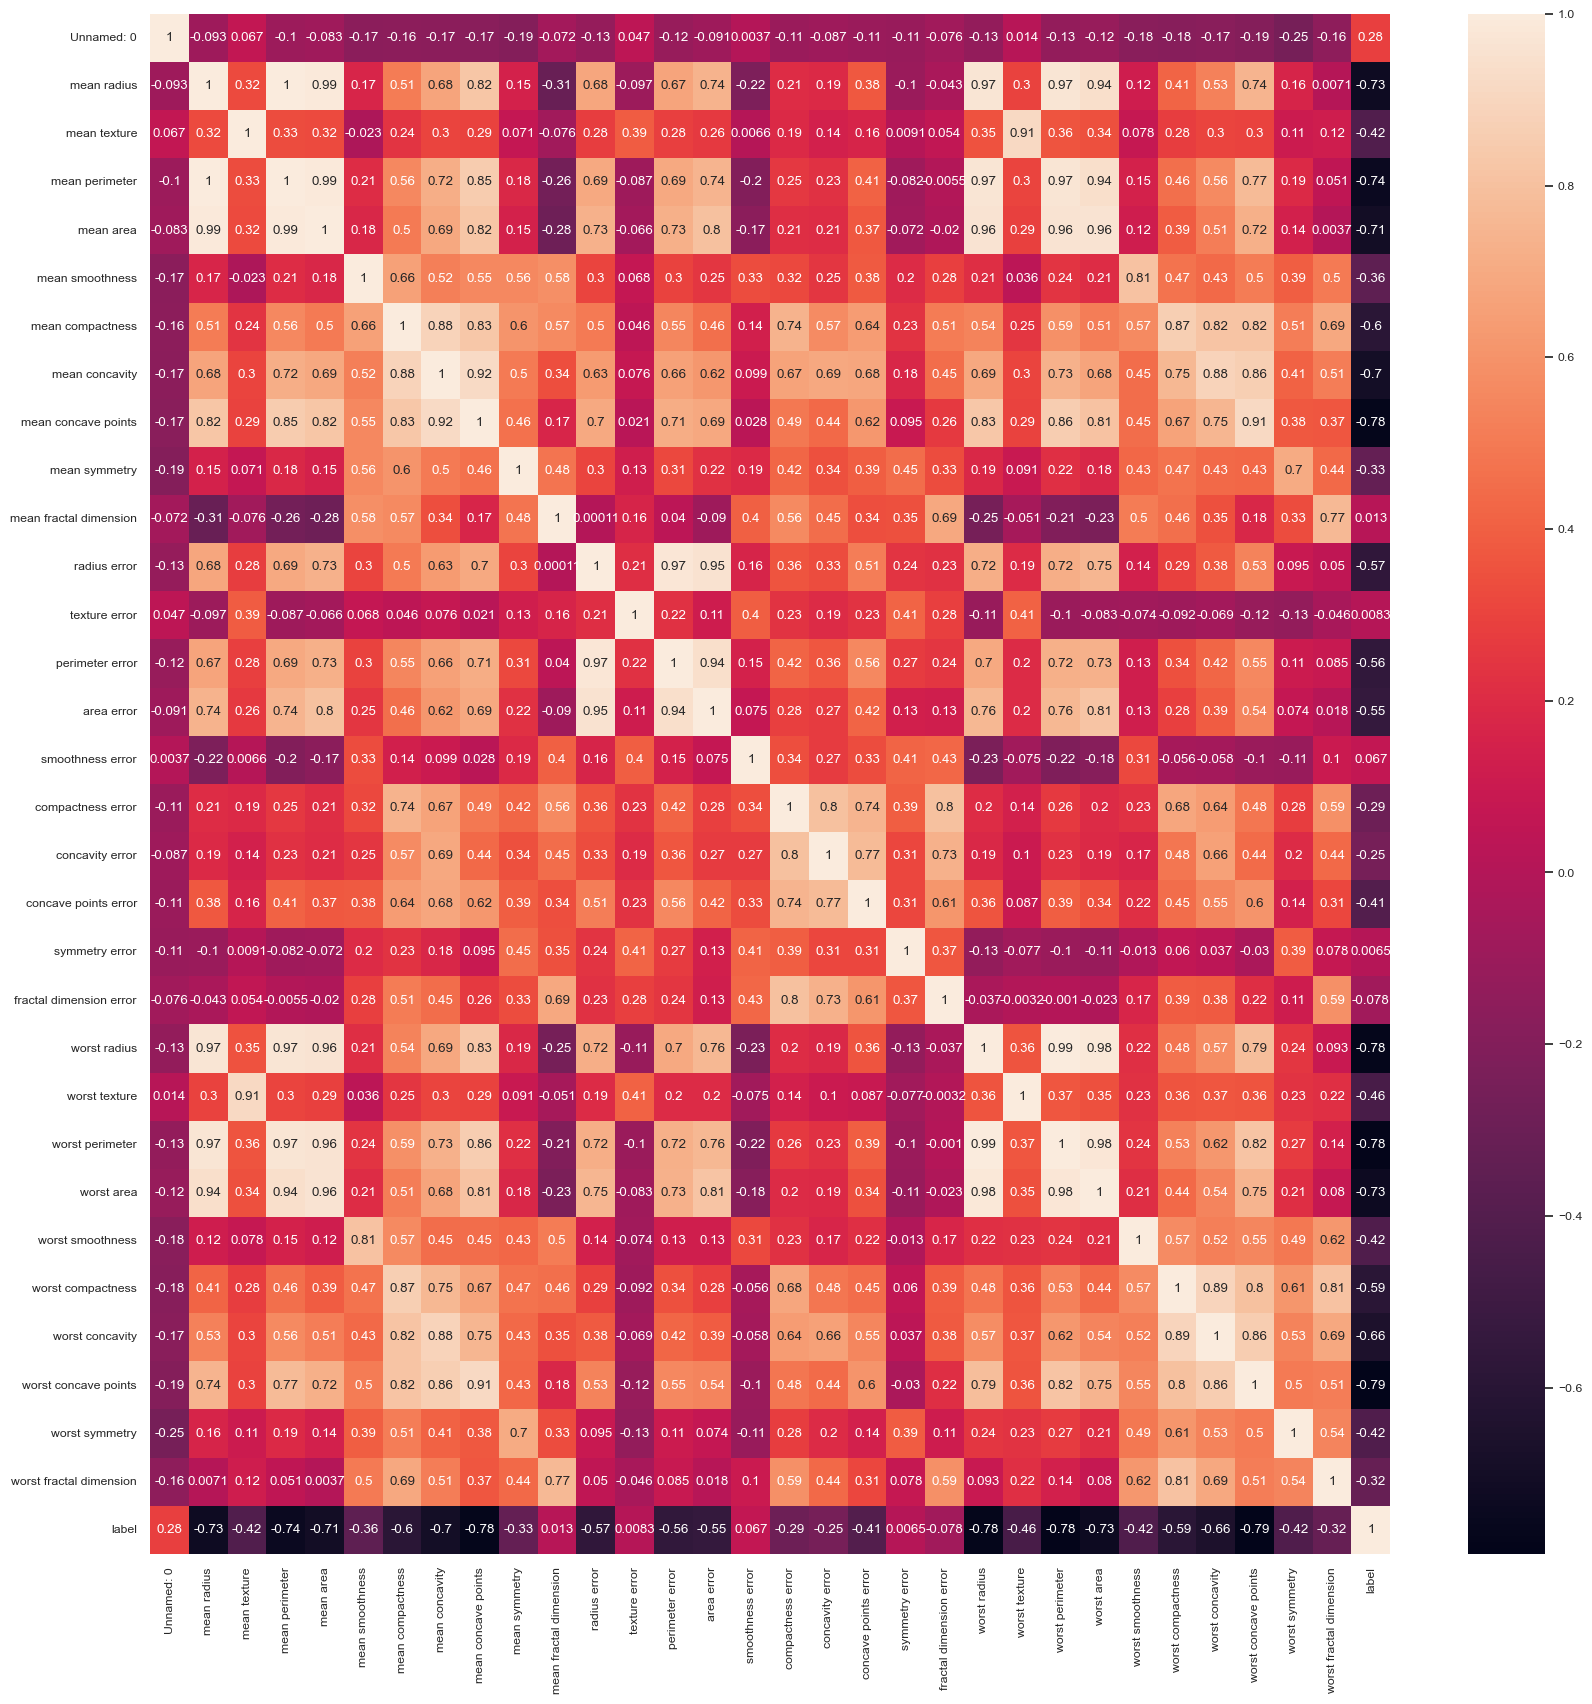

In [5]:
df_corr = df.corr()

plt.figure(figsize=(20, 20))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=True)
plt.show()

In [7]:
y = df["worst area"]
X = df.drop("worst area", axis=1)
X = X.values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [9]:
model = models.Sequential([
    layers.Dense(164, activation="relu", input_shape=(X.shape[1], )),
    layers.Dropout(0.1),
    layers.Dense(164, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50


d:\hanyeowon\Coding\pythonworks\deep\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1032707.6875 - mse: 1032707.6875 - val_loss: 1475774.2500 - val_mse: 1475774.2500
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1004323.9375 - mse: 1004323.9375 - val_loss: 1415159.7500 - val_mse: 1415159.7500
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 926865.2500 - mse: 926865.2500 - val_loss: 1255087.5000 - val_mse: 1255087.5000
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 760707.6875 - mse: 760707.6875 - val_loss: 946251.0625 - val_mse: 946251.0625
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 501717.8438 - mse: 501717.8438 - val_loss: 540729.1875 - val_mse: 540729.1875
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 247589.8750 - mse: 247589.8750 - val_loss: 264614.0312 - val_mse: 264614.0312
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 134287.1875 - mse: 134287.1875 - val_loss: 175046.8906 - val_mse: 175046.8906
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/ste

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


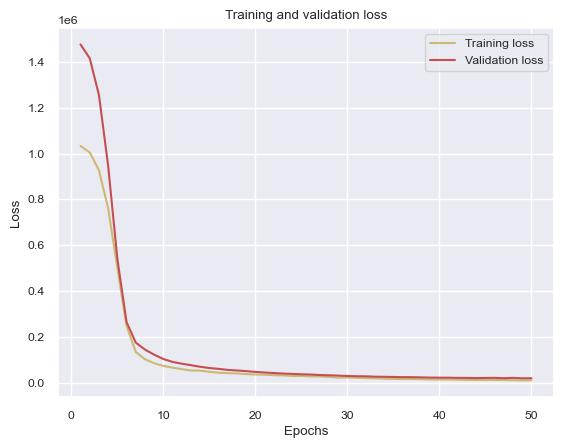

In [10]:
y_pred = model.predict(X_test_scaled)

loss = history.history['loss']
val_loss = history.history['val_loss']
mse = history.history['mse']
val_mse = history.history['val_mse']

epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
print(loss)
print(val_loss)
print(mse)
print(val_mse)
print(y_test.shape)
print(y_pred.shape)
print(y_test)
print(y_pred)

[1032707.6875, 1004323.9375, 926865.25, 760707.6875, 501717.84375, 247589.875, 134287.1875, 102366.1640625, 85124.625, 73330.484375, 65830.1796875, 59393.01171875, 53281.7578125, 52970.3125, 47520.76953125, 43558.7109375, 41956.8203125, 40139.015625, 37672.15234375, 35962.95703125, 35201.06640625, 32959.50390625, 32060.716796875, 29561.28515625, 29526.744140625, 27439.017578125, 27390.19921875, 25389.49609375, 22187.107421875, 22992.23828125, 21670.580078125, 20138.626953125, 19382.890625, 17873.125, 17028.099609375, 16034.7275390625, 16306.1337890625, 15430.8671875, 14325.9482421875, 14002.435546875, 14130.9833984375, 13355.21484375, 12209.6416015625, 12036.7431640625, 12001.892578125, 11956.376953125, 11740.01953125, 11007.611328125, 9926.3720703125, 10541.181640625]
[1475774.25, 1415159.75, 1255087.5, 946251.0625, 540729.1875, 264614.03125, 175046.890625, 144642.328125, 122550.421875, 103451.28125, 90651.734375, 83055.90625, 76555.0625, 69532.8984375, 64178.37890625, 60474.77734375,

In [12]:
from sklearn.metrics import r2_score
print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: 0.9503347446108844
